In [1]:
from scipy.integrate import solve_ivp
from rebinding.efflux_model_collection import washout_zero_bound_extra_compartment
import matplotlib.pyplot as plt
from rebinding.fig_utils import defaultStyle, save_fig
import numpy as np
defaultStyle(fs=14)

In [2]:
# mu dominates
kd = 0.1
kon = 10
koff = kon * kd
mu = 5
m = 1
k1 = 1e-3
k2 = 1e-1
f = k1 / k2

sol_mu = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 8],
    y0=[10 * m, m, 9 * m * f / (1 + f)],
    args=[0, 10, m, mu, k1, k2]
)
sol_koff = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 8],
    y0=[10 * m, m, 9 * m * f / (1 + f)],
    args=[0, 1, m, mu, k1, k2],
    max_step=0.05
)
sol_rebinding = solve_ivp(
    washout_zero_bound_extra_compartment,
    t_span=[0, 8],
    y0=[10 * m, m, 9 * m * f / (1 + f)],
    args=[kon, 1, m, mu, k1, k2],
    max_step=0.05
)

Saving figure Washout_schematic


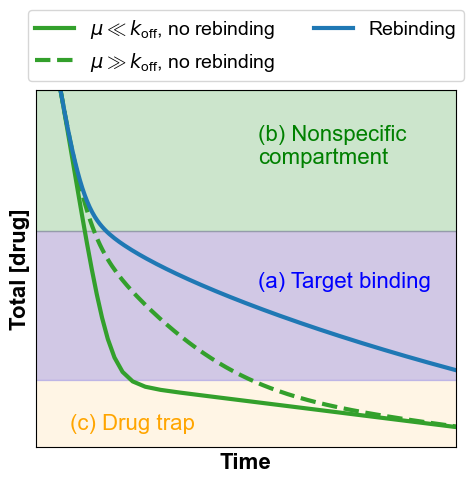

In [3]:
colors = plt.cm.Paired.colors

_, ax = plt.subplots(figsize=(5, 5))
ax.plot(sol_mu.t, sol_mu.y[0], lw=3, label=r"$\mu \ll k_{\mathrm{off}}$, no rebinding", color=colors[3])
ax.plot(sol_koff.t, sol_koff.y[0], lw=3, label=r"$\mu \gg k_{\mathrm{off}}$, no rebinding", color=colors[3], ls="--")
ax.plot(sol_rebinding.t, sol_rebinding.y[0], lw=3, label=r"Rebinding", color=colors[1])
ax.set_yscale("log")
ax.set_ylim([3e-2, 10 * m])
ax.tick_params(
    axis="x",
    which="both",
    bottom=False,
    top=False,
    labelbottom=False,
)
ax.tick_params(
    axis="y",
    which="both",
    left=False,
    labelleft=False,
)
ax.set_xlim([-0.5, 8])
ax.fill_between([-5, 50], y1=[m, m], y2=[10 * m, 10 * m], color="green", alpha=0.2)
ax.fill_between([-5, 50], y1=[m, m], y2=[9e-2] * 2, color="blue", alpha=0.2)
ax.fill_between([-5, 50], y1=[m, m], y2=[1e-2] * 2, color="orange", alpha=0.1)

ax.text(4, 3, "(b) Nonspecific\ncompartment", fontsize=16, color="green")
ax.text(4, 0.4, "(a) Target binding", fontsize=16, color="blue")
ax.text(0.2, 0.04, "(c) Drug trap", fontsize=16, color="orange")
t = sol_mu.t
# ax.plot(t, 0.1 * np.exp(-k2 * t))

ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.25), fontsize=14, ncols=2)

ax.set_xlabel("Time", fontweight="bold", fontsize=16)
ax.set_ylabel("Total [drug]", fontweight="bold", fontsize=16)
save_fig("Washout_schematic", fmt="png", dpi=300)

Saving figure fig5-schematic


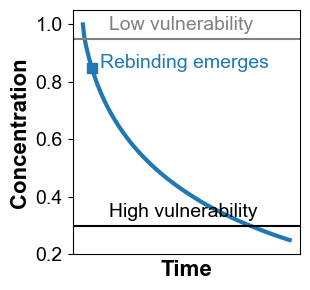

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
from rebinding.efflux_model_collection import washout_zero_bound

kd = 0.1
kon = 10
koff = kon * kd
mu = 10
m = 10

sol_rebinding = solve_ivp(
    washout_zero_bound,
    t_span=[0, 8],
    y0=[10 * kd + m, m],
    args=[kon, koff, m, mu],
    max_step=0.05,
)

_, ax = plt.subplots(figsize=(3.2, 3))
ax.plot(sol_rebinding.t, sol_rebinding.y[1] / m, lw=3, label="Site occupancy", color=colors[1])

transit = m - m * np.sqrt(kd / m)
t_transit = sol_rebinding.t[np.where(sol_rebinding.y[0] < transit)[0][0]]
s_transit = sol_rebinding.y[1][np.where(sol_rebinding.y[0] < transit)[0][0]] / m

ax.scatter([t_transit], [s_transit], s=50, marker="s")
ax.axhline(0.3, color="k")
ax.axhline(0.95, color="gray")
ax.text(1, 0.3 + .03, "High vulnerability", fontsize=14, color="k")
ax.text(1, 0.95 + .03, "Low vulnerability", fontsize=14, color="gray")
ax.text(t_transit + 0.3, s_transit, "Rebinding emerges", fontsize=14, color=colors[1])

ax.tick_params(
    axis="x",
    which="both",
    bottom=False,
    top=False,
    labelbottom=False,
)
ax.tick_params(
    axis="y",
    which="both",
    # left=False,
    # labelleft=False,
)

ax.set_xlabel("Time", fontweight="bold", fontsize=16)
ax.set_ylabel("Concentration", fontweight="bold", fontsize=16)
ax.set_ylim([0.2, 1.05])
save_fig("fig5-schematic", fmt="png", dpi=300)

Saving figure fig6-schematic


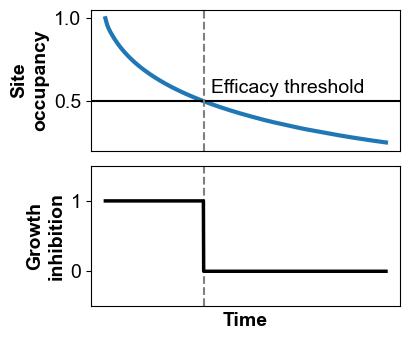

In [7]:
kd = 0.1
kon = 10
koff = kon * kd
mu = 10
m = 10

sol_rebinding = solve_ivp(
    washout_zero_bound,
    t_span=[0, 8],
    y0=[10 * kd + m, m],
    args=[kon, koff, m, mu],
    max_step=0.05,
)

_, (ax, bx) = plt.subplots(2, 1, figsize=(4.2, 3.5))
ax.plot(sol_rebinding.t, sol_rebinding.y[1] / m, lw=3, label="Site occupancy", color=colors[1])

ax.axhline(0.5, color="k")
ax.text(3, 0.5 + .05, "Efficacy threshold", fontsize=14, color="k")

t_thresh = sol_rebinding.t[np.where(sol_rebinding.y[1] < m * 0.5)[0][0]]
for cx in [ax, bx]:
    cx.tick_params(
        axis="x",
        which="both",
        bottom=False,
        top=False,
        labelbottom=False,
    )
    cx.axvline(t_thresh, ls="--", c="gray")
x = np.linspace(0, 8, 1000)
bx.plot(x, x < t_thresh, c="k", lw=2.5)

bx.set_xlabel("Time", fontweight="bold", fontsize=14)
ax.set_ylabel("Site\noccupancy", fontweight="bold", fontsize=14)
bx.set_ylabel("Growth\ninhibition", fontweight="bold", fontsize=14)
ax.set_ylim([0.2, 1.05])
bx.set_ylim([-0.5, 1.5])
save_fig("fig6-schematic", fmt="png", dpi=300)